# CBGT reference patterns and clustering validation

This notebook generates the simulated SPN panels for Fig. 1C–D. <br>
This notebook reads the 300 original network folders under `data/source/cbgt/networks/` and writes the standardized tables used by later notebooks.

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.insert(0, str(PROJECT_ROOT))

### Load the 300 CBGT networks and construct shared analysis tables

Each `network_<id>/` folder must contain `binned_firing_rates.csv` and `data_conf.csv`.<br>
The speed-index pickles remain directly under `data/source/cbgt/`.

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from spn_figures.config import DERIVED, FIGURES, SOURCE
from spn_figures.io import read_csv, save_figure, write_csv
from spn_figures.clustering import cbgt_ground_truth_clustering
from spn_figures.datasets import (
    build_cbgt_manifest,
    load_cbgt_state_bins,
    prepare_cbgt_tables,
)
from spn_figures.plotting import (
    cbgt_speed_correlations,
    plot_cbgt_profiles,
    plot_clustering_validation,
    plot_correlation_matrices,
)

cbgt_dir = SOURCE / "cbgt"
networks_dir = cbgt_dir / "networks"
manifest_path = cbgt_dir / "network_manifest.csv"
out_dir = DERIVED / "cbgt"
out_dir.mkdir(parents=True, exist_ok=True)

manifest = build_cbgt_manifest(networks_dir, cbgt_dir)
write_csv(manifest, manifest_path)

features, vectors, activity, predecision_activity = prepare_cbgt_tables(
    manifest_path,
    networks_dir,
)
state_bins = load_cbgt_state_bins(manifest_path, networks_dir)

features.to_csv(out_dir / "spn_features.csv.gz", index=False)
vectors.to_csv(out_dir / "spn_trial_vectors.csv.gz", index=False)
activity.to_csv(out_dir / "last6_trial_activity.csv.gz", index=False)
predecision_activity.to_csv(out_dir / "predecision_activity.csv.gz", index=False)
state_bins.to_csv(out_dir / "trial_state_bins.csv.gz", index=False)

features.shape, activity.shape, predecision_activity.shape, state_bins.shape

((1200, 17), (359856, 8), (690824, 8), (172706, 13))

### Fig. 1C: simulated SPN activity patterns

In [3]:
clustering = cbgt_ground_truth_clustering(features, vectors)

labeled_features = features.copy()
labeled_features["stage1_label"] = clustering["stage1_labels"]
labeled_features["stage2_channel_label"] = clustering["stage2_channel_labels"]
labeled_features["stage2_label"] = clustering["stage2_labels"]
labeled_features["stage1_repaired_for_stage2"] = labeled_features["network_id"].isin(
    clustering["repaired_networks"]
)
labeled_features.to_csv(
    out_dir / "spn_features_with_cluster_labels.csv.gz",
    index=False,
)

metrics = pd.DataFrame(
    [
        {
            "analysis": "left_vs_right",
            "adjusted_rand_index": clustering["stage1_ari"],
            "accuracy": clustering["stage1_accuracy"],
        },
        {
            "analysis": "four_subtypes",
            "adjusted_rand_index": clustering["stage2_ari"],
            "accuracy": clustering["stage2_accuracy"],
        },
    ]
)
write_csv(metrics, out_dir / "clustering_validation.csv")
write_csv(
    clustering["stage2_diagnostics"],
    out_dir / "stage2_within_network_diagnostics.csv",
)

print(f"Stage 1 networks repaired to a 2/2 split: {len(clustering['repaired_networks'])}")
metrics

Stage 1 networks repaired to a 2/2 split: 5


,analysis,adjusted_rand_index,accuracy
0,left_vs_right,0.983389,0.995833
1,four_subtypes,0.873045,0.950000


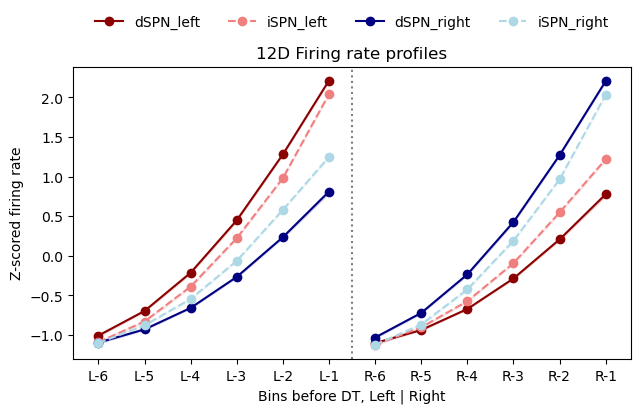

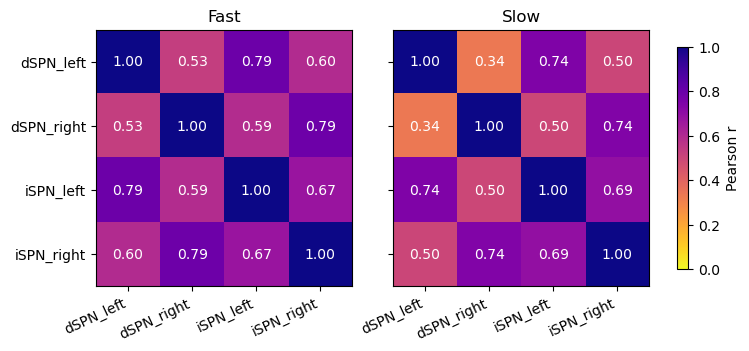

In [4]:
fig, _ = plot_cbgt_profiles(features)
save_figure(fig, FIGURES / "main" / "Fig1C_i_cbgt_12D_profiles")
plt.show()

matrices = cbgt_speed_correlations(activity)
fig, axes = plot_correlation_matrices(matrices)

for ax in axes:
    ax.images[0].set_clim(0, 1)
cbar_ax = fig.axes[-1]
if cbar_ax.collections:
    cbar = cbar_ax.collections[0].colorbar
    if cbar is not None:
        cbar.mappable.set_clim(0, 1)
        cbar.set_ticks([0, 0.25, 0.5, 0.75, 1.0])
        cbar.update_normal(axes[0].images[0])

save_figure(fig, FIGURES / "main" / "Fig1C_ii_cbgt_fast_slow_correlations")
plt.show()

### Fig. 1D: two-stage subtype inference and validation

Stage 1 uses global Ward clustering of the 12D profiles. <br>
Stage 2 is evaluated separately within each network: the lower cross-channel correlation candidate is labeled dSPN and the higher candidate is labeled iSPN.

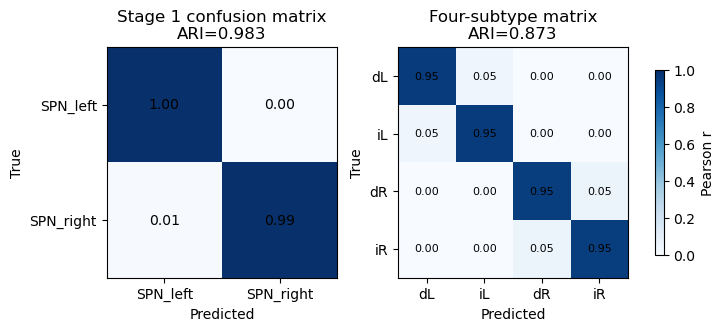

In [5]:
fig = plot_clustering_validation(features, vectors, clustering)
save_figure(fig, FIGURES / "main" / "Fig1D_two_stage_clustering")
plt.show()